In [5]:
# %load_ext autoreload
# %autoreload 2
# import numpy as np
# import matplotlib.pyplot as plt
# from coffea import util
# from coffea.processor import accumulate
# import os
# import re
# import pandas as pd
# import hist
# import matplotlib as mpl
# import mplhep
# import sys

# sys.path.append("../analysisTools/")
# import plotTools as ptools
# import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
%load_ext autoreload
%autoreload 2
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import sys
import importlib
import coffea.util as util
import time
import json
import os
import numba as nb
import awkward.numba
from scipy.stats import binned_statistic

sys.path.append("../analysisTools/")
from analysisTools import Analyzer
from analysisTools import loadSchema
import analysisTools as tools
import analysisSubroutines as routines

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# #coffea output file
# f_sig = "../coffea/signal_2022/signal_2022_Mchi_10_30_50_aEM.coffea"
# #Nested Dictionary:
# sig_histo = util.load(f_sig) [0]


In [8]:
sample_cfg = "../configs/sample_configs/signal_2022_Mchi_10_30_50_aEM.json"
with open(sample_cfg,"r") as fin:
    sig_cfg = json.load(fin)
loc0 = sig_cfg[0]['location']
loc1 = sig_cfg[1]['location']
loc2 = sig_cfg[2]['location']

In [10]:
#See the quantities in the root file:
t0 = uproot.open(loc0)['ntuples/outT']
t1 = uproot.open(loc1)['ntuples/outT']
t2 = uproot.open(loc2)['ntuples/outT']

In [11]:
# Trigger used
met_trig0=t0["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()
met_trig1=t1["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()
met_trig2=t2["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()

In [12]:
#Cut for m1=10
PFMET_pt0=t0["PFMET_pt"].array()

CaloMET_pt0=t0["CaloMET_pt"].array()
diff0= abs(PFMET_pt0-CaloMET_pt0)

r0=diff0/(CaloMET_pt0)
print ("Value of ratio:",r0)
cut_sig0=(r0 <0.5)


#Cut for m1=30

PFMET_pt1=t1["PFMET_pt"].array()

CaloMET_pt1=t1["CaloMET_pt"].array()
diff1= abs(PFMET_pt1-CaloMET_pt1)

r1=diff1/(CaloMET_pt1)
cut_sig1=(r1 <0.5)


#Cut for m1=50

PFMET_pt2=t2["PFMET_pt"].array()

CaloMET_pt2=t2["CaloMET_pt"].array()
diff2= abs(PFMET_pt2-CaloMET_pt2)

r2=diff2/(CaloMET_pt2)

cut_sig2=(r2 <0.5)


Value of ratio: [0.622, 0.167, 1.08, 0.0372, 0.65, 0.537, ... 0.0592, 0.207, 0.524, 0.183, 0.442]


In [14]:
#Denominator:
pfmet_pass2 = PFMET_pt2[cut_sig2]

met_trig_pass2 = met_trig2[cut_sig2] 
#Numerator
pfmet_pass2[met_trig_pass2]




<Array [109, 206, 221, 292, ... 273, 183, 170] type='22154 * float32'>

10


TypeError: string indices must be integers

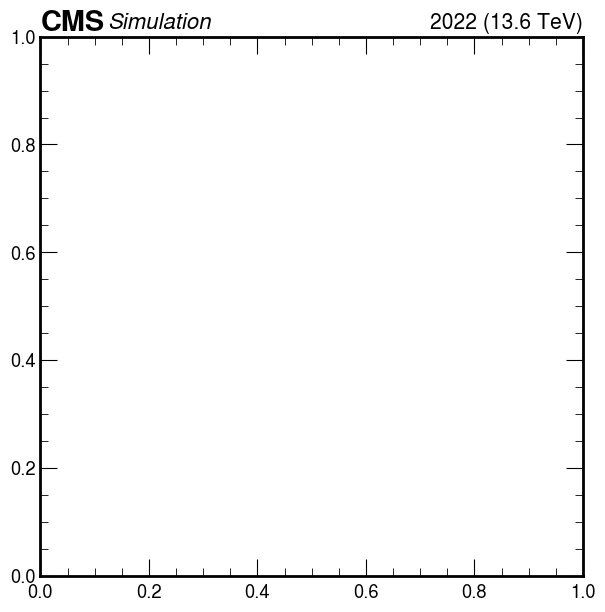

In [16]:
fig, ax = plt.subplots(figsize=(7,7))



# Plot settings
plot_dict = {
    'variable': 'pfmet_pass2',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': 1j,
    'xlim': [0,50],     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    'xlabel': "sel_vtx_pT",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': 'Events/0.1cm',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/',
    'outName': f'signal_cut1_sel_vtx_pT.png'
}
# signal points
m1s = [10,30,50]
deltas = [0.1]
ctaus = [10]

# Plot for variables signal points
for m1 in m1s:
    print (m1)
    for delta in deltas:
        for ctau in ctaus:
            ptools.plot_signal_1D(loc0, m1, delta, ctau, plot_dict, style_dict)


In [ ]:
fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta = 0.1
ctau = 10

# Plot settings
plot_dict = {
    'variable': 'PFMET',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': 1j,
    'xlim': [0,300],     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': True, 
    'xlabel': r"$E_T$ miss",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': 'Events/0.1cm',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/',
    'outName': f'signal_cut1_PFMET.png'
}
# signal points
m1s = [10,30,50]
deltas = [0.1]
ctaus = [10]

# Plot for variables signal points
for m1 in m1s:
    for delta in deltas:
        for ctau in ctaus:
            ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)


In [ ]:
fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta = 0.1
ctau = 10

# Plot settings
plot_dict = {
    'variable': 'sel_vtx_vxy100',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': 2j,
    'xlim': [0,60],     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    'xlabel': "Lxy (in cm)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': 'Events/0.1cm',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/',
    'outName': f'signal_cut1_Lxy_max10.png'
}

# signal points
m1s = [10, 30,50]
deltas = [0.1]
ctaus = [10]

# Plot for variables signal points
for m1 in m1s:
    for delta in deltas:
        for ctau in ctaus:
            ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)


In [ ]:
fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta = 0.1
ctau = 10

# Plot settings
plot_dict = {
    'variable': 'sel_vtx_dR',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': 1j,
    'xlim': [0,5],     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    'xlabel': "dR",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': 'Events/0.1cm',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/',
    'outName': f'signal_cut1_dR.png'
}

# signal points
m1s = [10, 30,50]
deltas = [0.1]
ctaus = [10]

# Plot for variables signal points
for m1 in m1s:
    for delta in deltas:
        for ctau in ctaus:
            ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)


In [ ]:
fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta = 0.1
ctau = 10

# Plot settings
plot_dict = {
    'variable': 'jetMETdPhi',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': 1j,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    'xlabel': 'jetMETdPhi',   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': 'Events/0.1cm',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/',
    'outName': f'signal_cut1_jetMETdPhi.png'
}

# signal points
m1s = [10, 30,50]
deltas = [0.1]
ctaus = [10]

# Plot for variables signal points
for m1 in m1s:
    for delta in deltas:
        for ctau in ctaus:
            ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)


In [ ]:
fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta = 0.1
ctau = 10

# Plot settings
plot_dict = {
    'variable': 'sel_vtx_METdPhi',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': 1j,
    'xlim': [0,3],     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    'xlabel': "sel_vtx_METdPhi",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': 'Events/0.1cm',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/',
    'outName': f'signal_cut1_METdPhi.png'
}

# signal points
m1s = [10, 30,50]
deltas = [0.1]
ctaus = [10]

# Plot for variables signal points
for m1 in m1s:
    for delta in deltas:
        for ctau in ctaus:
            ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
